# Simple Linear Regression Exercise

In this notebook you will implement a linear regression model in Python. 

**Objectives**  
At the end of the notebook you should be able to:
- define the relationship between two variables
- define the concepts of intercept and slope
- reproduce the equation of Linear Regression
- explain the concept behind OLS
- build a Linear Regression model with the statsmodels module in Python
- interpret the output of a Linear Regression model built with the statsmodels module

**Task 1**  
Let's look at a dataset which is about Car seats. It includes the sales of child car seats at 400 different stores.
You can find the data in the data folder ('data/Carseats.csv').

It contains 400 observations for 400 different stores on the following 11 variables:

```
Sales:         Unit sales (in thousands) at each location
CompPrice:     Price charged by competitor at each location
Income:        Community income level (in thousands of dollars)
Advertising:   Local advertising budget for company at each location (in thousands of dollars)
Population:    Population size in region (in thousands)
Price:         Price company charges for car seats at each site
ShelveLoc:     A factor with levels Bad, Good and Medium indicating the quality of the shelving location
for the car seats at each site
Age:           Average age of the local population
Education:     Education level at each location
Urban:         A factor with levels No and Yes to indicate whether the store is in an urban or rural location
US:            A factor with levels No and Yes to indicate whether the store is in the US or not
```

-----
**Task**  
A company that makes these carseats want to predict their sales -  based on different factors. 

As you may see, there a many variables which you could include to help the company in redicting their sales. However, at this point we want to focus on one variable.  
**Your task is, to use the variable price as independent variable to predict Sales (nr of sales).**


Import all necessary libraries and read in the data:

In [58]:
import pandas as pd
import statsmodels.api as sms
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

1. Read in carseats data and get an overview of the data.

In [59]:

df=pd.read_csv("./data/Carseats.csv")

In [60]:
df

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


2.a) Create scatterplot showing the relationship between price and Sales.


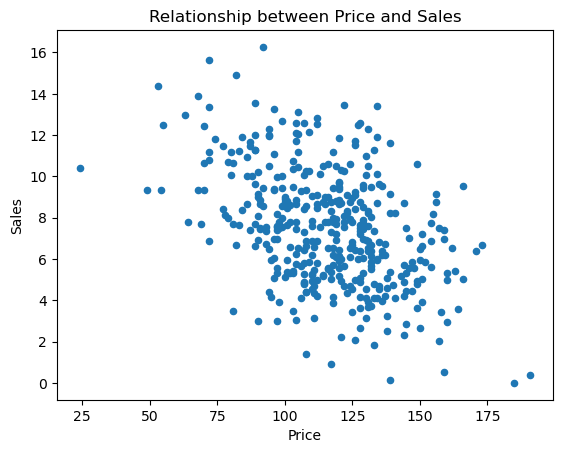

In [61]:
# plot the scatterplot again 
fig = df.plot(x='Price', 
                y='Sales', 
                kind='scatter')

# plot a title
plt.title("Relationship between Price and Sales");
plt.xlabel('Price')
plt.ylabel('Sales')
plt.show()

2.b) From visual inspection, what is the relationship between the variables?

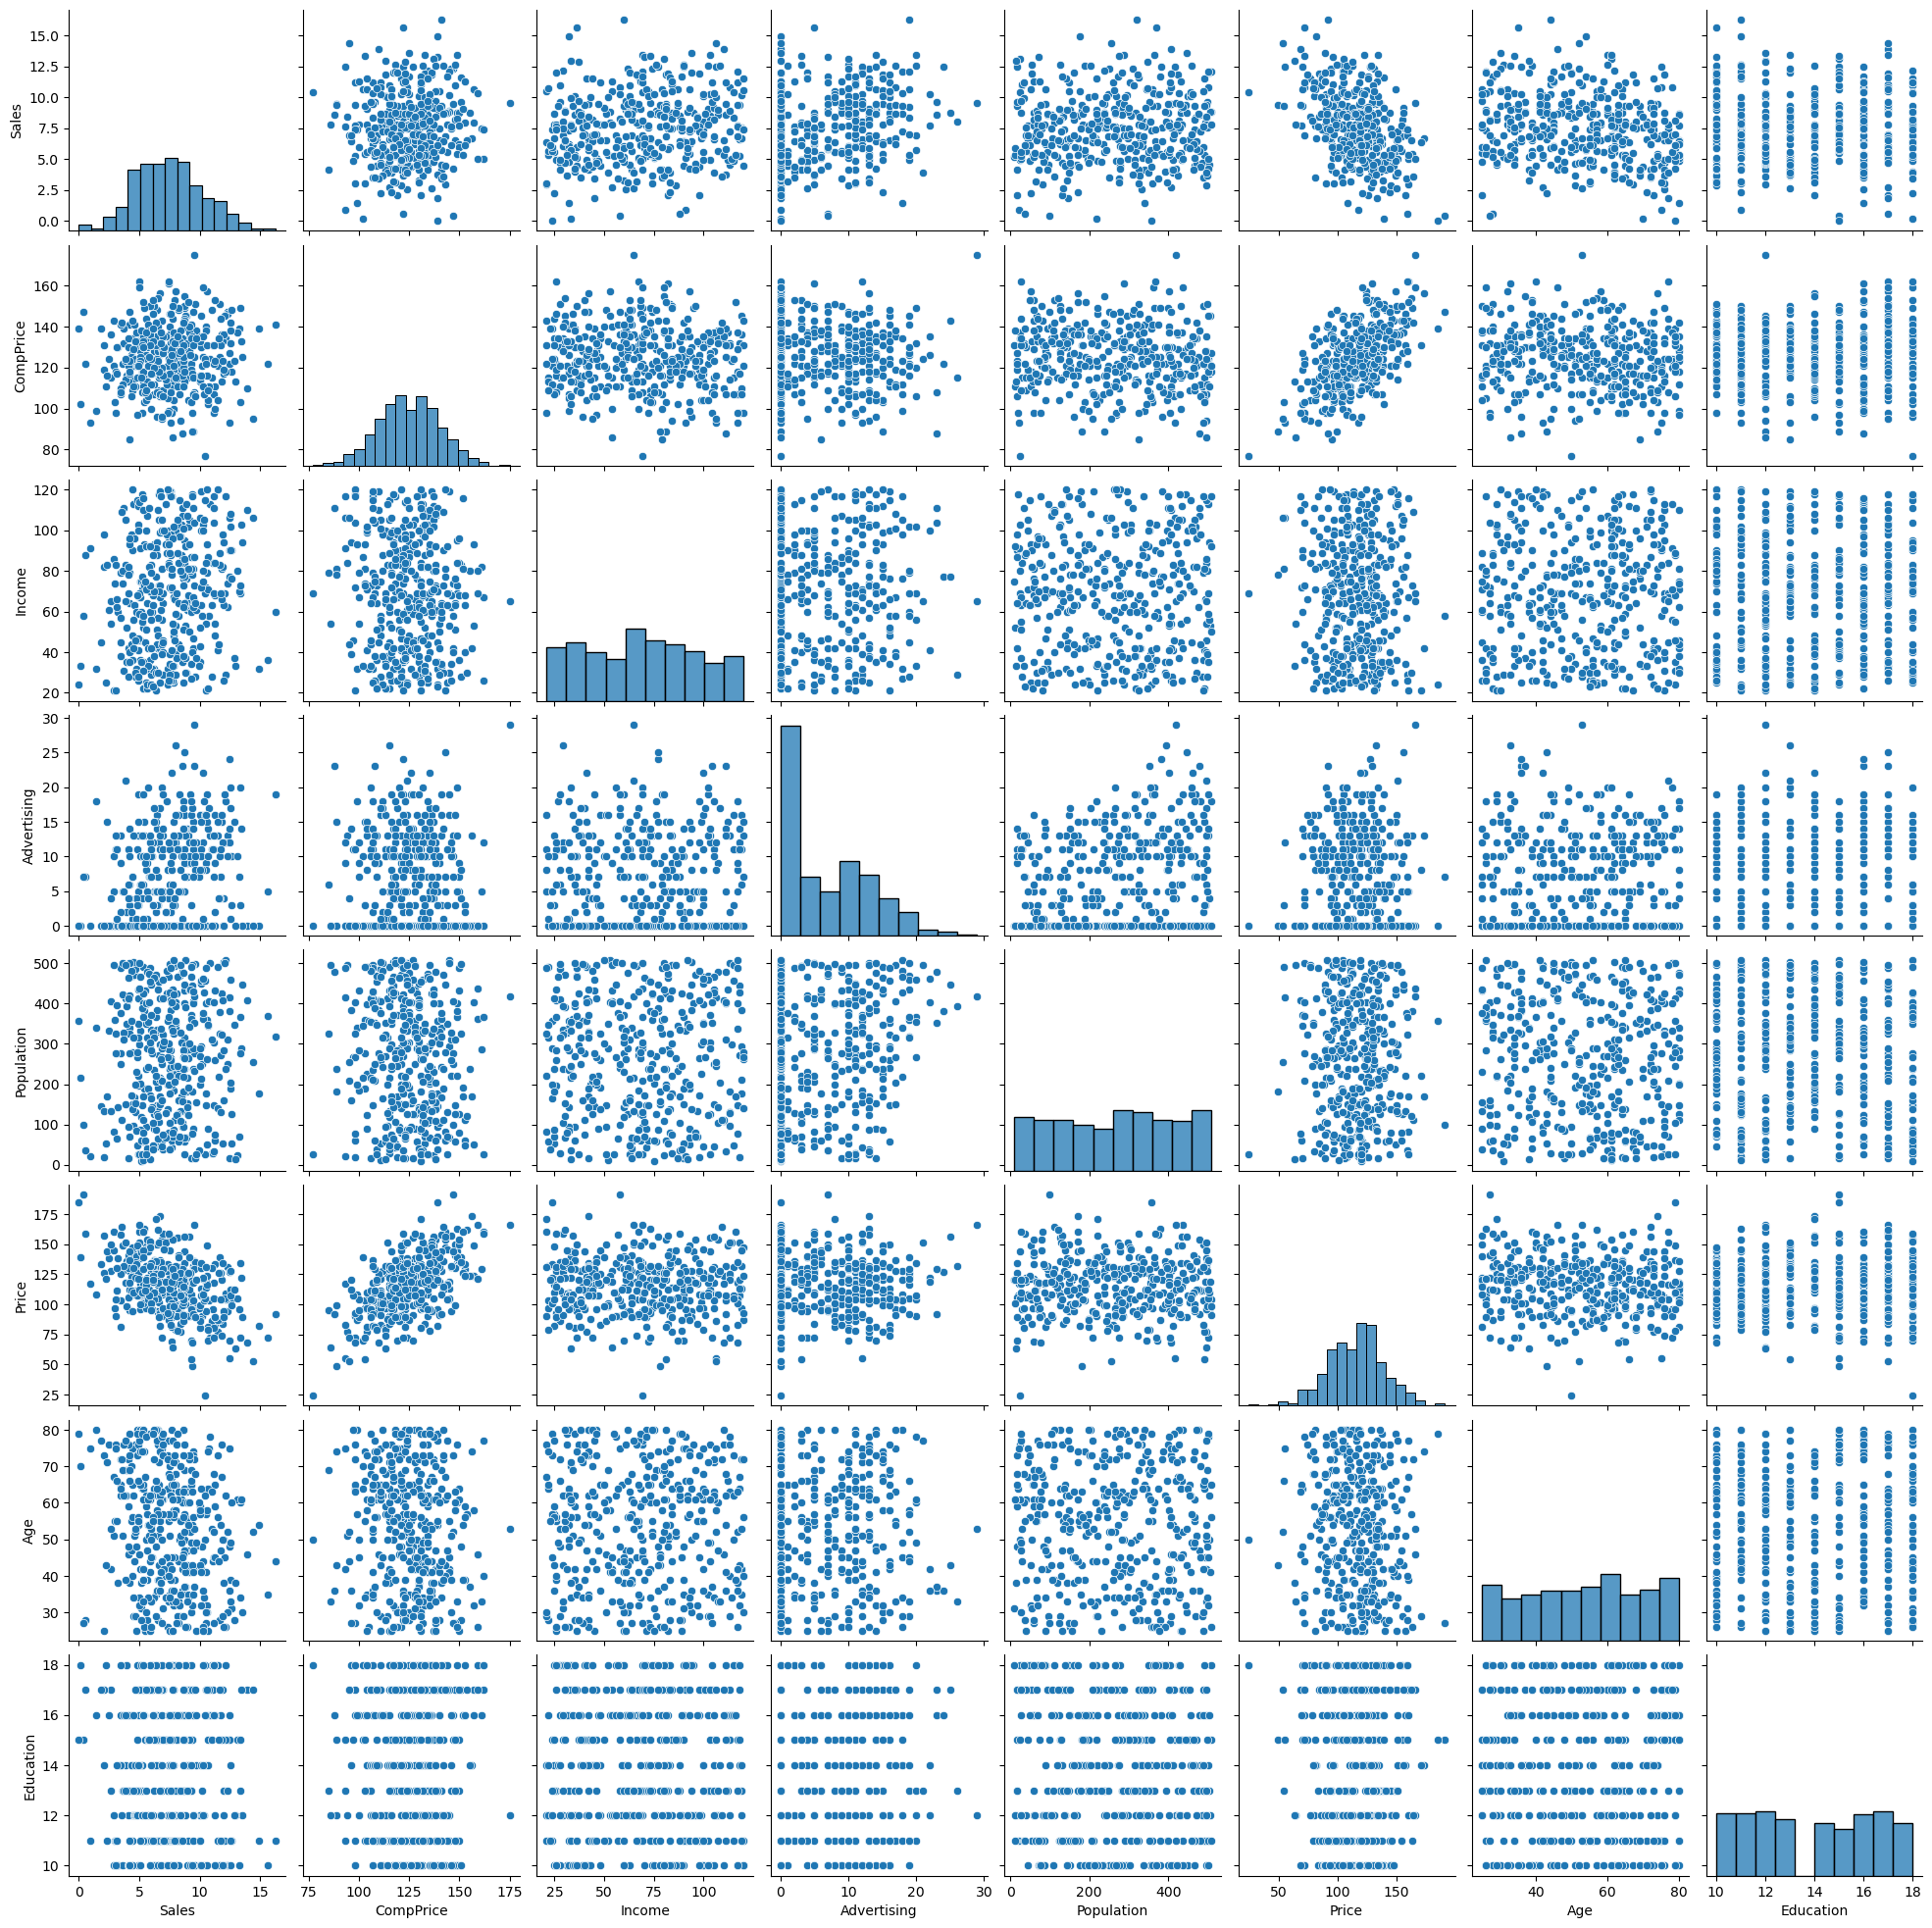

In [62]:
sns.pairplot(df)
plt.show()


2.c) Which other variables could explain variance in sales? Plot them against sales.
<br>
<details><summary>
Click here for a suggestion on how to easily vizualise:
</summary>
... there is a seaborn plot called pairplot, syntax: sns.pairplot(data)
</details>


3. Fit a simple linear regression with sales as dependent and price as independent variable using statsmodel OLS. 

In [63]:
# import the statsmodels.api module
import statsmodels.api as sm

In [64]:
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [65]:
# Choose the independent variable, the predictor X
X = df['Price']

# Define dependent variable (since it's always a single variable, we can use dot notation here)
y = df['Sales']

In [66]:
display(X.head())

0    120
1     83
2     80
3     97
4    128
Name: Price, dtype: int64

In [67]:
display(y.head())

0     9.50
1    11.22
2    10.06
3     7.40
4     4.15
Name: Sales, dtype: float64

In [68]:
# Since our statsmodel OLS model needs an adjustable intercept, we add a column of 1s to:
X = sm.add_constant(X)
display(X.head())

,const,Price
0,1.0,120
1,1.0,83
2,1.0,80
3,1.0,97
4,1.0,128


In [69]:
# create an OLS model
our_model = sm.OLS(y, X)

# use the data to calculate the intercept and slope
model_results = our_model.fit()

4.a) Print out the model summary. 

In [70]:
# return the output of the model
model_results.summary() # summary contains eg. 'const' (intercept) and 'slope' of the regression equation.

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.198
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     98.25
Date:                Thu, 09 Oct 2025   Prob (F-statistic):           7.62e-21
Time:                        15:30:58   Log-Likelihood:                -938.23
No. Observations:                 400   AIC:                             1880.
Df Residuals:                     398   BIC:                             1888.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         13.6419      0.633     21.558      0.000      12.398      14.886
Price         -0.0531      0.005     -9.912      0.000      -0.064      -0.043
==============================================================================
Omnibus:                        2.537   Durbin-Watson:                   1.892
Prob(Omnibus):                  0.281   Jarque-Bera (JB):                2.611
Skew:                           0.175   Prob(JB):                        0.271
Kurtosis:                       2.816   Cond. No.                         591.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

4.b) What are the intercept and slope of your regression line?


In [71]:
intercept, slope = model_results.params

print(f'intercept: {intercept}, slope: {slope}')

intercept: 13.641915176780923, slope: -0.053073018496316016


4.c) Interpret the intercept and slope coefficients in terms the Carseats company would understand.

In [72]:
# Negative effect of price on the sales: sales= -0.053*price+13.64

5. Calculate and interpret the value of R_squared.  

In [73]:
print("R^2:", model_results.rsquared)

R^2: 0.19798115021119456


6. What is the 95% confidence interval for the price?  

In [74]:
#95% CI: (-0.064, -0.043)

7. Is the price a significant predictor of the Carseat sales? Why or why not?

In [75]:
# P-value is 0.000 which is less than 0.05. it indicates that there is a statistically significant relationship between the term and the response.

8. Use the least squares line to estimate the sales if the price of a carseat is 150$.   
Hint:  
model.predict(…)  
The values you want to predict need to be located in an array together with a constant.


In [76]:
# New data to predict — must include a constant term too
X_new = np.array([[1, 150]])  # [constant, feature value]

# Generate predictions
predictions = model_results.predict(X_new)

print(predictions)


[5.6809624]


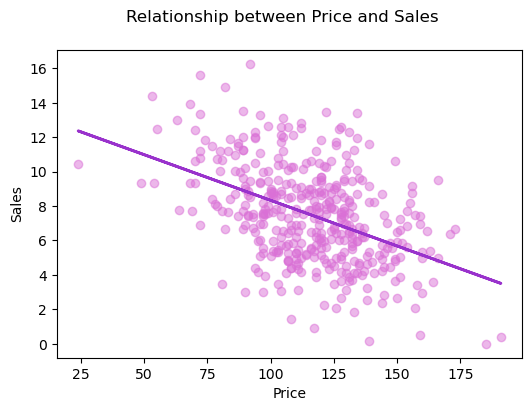

In [77]:
# Plotting the results of our model
fig, ax = plt.subplots(figsize=(6, 4))

x = df['Price']
y = df['Sales']

# add data points
ax.scatter(x, y, alpha=0.5, color='orchid')
fig.suptitle('Relationship between Price and Sales')

# plotting the regression line with the help of our calculated intercept and slope variables
ax.plot(x, x*slope+intercept, '-', color='darkorchid', linewidth=2);
ax.set_ylabel("Sales");
ax.set_xlabel("Price");
plt.show()